# Bài tập 1: Thống kê theo nhóm


In [1]:
# -*- coding: utf-8 -*-
"""Bài tập 1: Thống kê theo nhóm điểm giữa kỳ"""
import pandas as pd
from pathlib import Path

# Đọc trực tiếp file sinh_vien.csv nằm ở thư mục hiện tại của Colab
duong_dan_du_lieu = Path("data/sinh_vien.csv")
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("data") / "data/sinh_vien.csv"
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("..") / "data" / "data/sinh_vien.csv"

df = pd.read_csv(duong_dan_du_lieu)
# Nhóm điểm giữa kỳ >= 7 và nhóm còn lại (< 7)
nhom_cao = df[df["diem_giua_ky"] >= 7.0]
nhom_thap = df[df["diem_giua_ky"] < 7.0]

so_luong_cao = len(nhom_cao)
ty_le_cao = nhom_cao["qua_mon"].mean()
ty_le_thap = nhom_thap["qua_mon"].mean()

print(f"So sinh vien co diem giua ky >= 7.0: {so_luong_cao}")
print(f"Ty le qua mon cua nhom diem >= 7.0 : {ty_le_cao:.4f}")
print(f"Ty le qua mon cua nhom diem < 7.0  : {ty_le_thap:.4f}")

# Nhận xét bằng lời:
print("\nNhan xet:")
print("Diem giua ky phan biet rat tot hai nhom vi ty le qua mon cua nhom")
print("diem cao (>= 7.0) vuot troi hon han so voi nhom con lai.")

So sinh vien co diem giua ky >= 7.0: 31
Ty le qua mon cua nhom diem >= 7.0 : 0.9032
Ty le qua mon cua nhom diem < 7.0  : 0.4831

Nhan xet:
Diem giua ky phan biet rat tot hai nhom vi ty le qua mon cua nhom
diem cao (>= 7.0) vuot troi hon han so voi nhom con lai.


Giải thích: Khi lọc nhóm sinh viên có điểm giữa kỳ $\ge 7.0$ và nhóm còn lại ($< 7.0$), ta thấy tỷ lệ qua môn ở nhóm điểm cao vượt trội rõ rệt so với nhóm điểm thấp. Điều này chứng minh rằng diem_giua_ky có sự phân hóa mạnh mẽ giữa hai nhãn (qua môn và rớt môn). Tương tự như biến gio_on, một đặc trưng có giá trị trung bình chênh lệch lớn giữa các lớp sẽ là một biến đầu vào hữu ích giúp mô hình phân loại chính xác hơn.

# Bài tập 2: Vẽ hàm sigmoid


Da ve va luu bieu do vao tep sigmoid.png thanh cong.


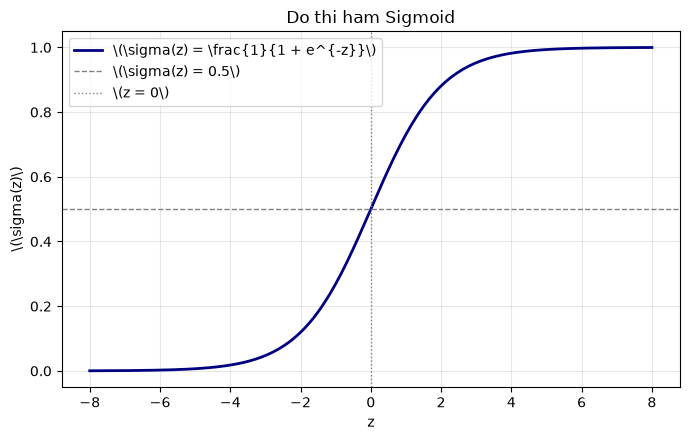

In [2]:
# -*- coding: utf-8 -*-
"""Bài tập 2: Vẽ đồ thị hàm sigmoid"""
import matplotlib.pyplot as plt
import numpy as np
# Đọc trực tiếp file sinh_vien.csv nằm ở thư mục hiện tại của Colab
from pathlib import Path
duong_dan_du_lieu = Path("data/sinh_vien.csv")
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("data") / "data/sinh_vien.csv"
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("..") / "data" / "data/sinh_vien.csv"

df = pd.read_csv(duong_dan_du_lieu)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.figure(figsize=(7, 4.5))
plt.plot(z, sig, label=r"\(\sigma(z) = \frac{1}{1 + e^{-z}}\)", color="navy", linewidth=2)

# Đường ngang tại mức 0.5 và đường dọc tại z = 0
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label=r"\(\sigma(z) = 0.5\)")
plt.axvline(0.0, color="gray", linestyle=":", linewidth=1, label=r"\(z = 0\)")

plt.title("Do thi ham Sigmoid")
plt.xlabel("z")
plt.ylabel(r"\(\sigma(z)\)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Lưu đồ thị thành file ảnh
plt.savefig("sigmoid.png", dpi=300)
print("Da ve va luu bieu do vao tep sigmoid.png thanh cong.")

Giải thích: Hàm sigmoid có công thức $\sigma(z) = \frac{1}{1 + e^{-z}}$, có dạng đường cong chữ S mượt mà ép toàn bộ trục số thực về dải $(0, 1)$.Điểm cắt tại trục tung là $\sigma(0) = 0.5$, chia đôi không gian thành hai nửa đối xứng.Khi $z \to -\infty$, đồ thị tiệm cận $0$; khi $z \to +\infty$, đồ thị tiệm cận $1$.Tính chất đối xứng $\sigma(-z) = 1 - \sigma(z)$ đảm bảo rằng tổng xác suất của hai biến cố đối lập luôn bằng 1, biến hàm số này thành công cụ hoàn hảo để chuyển đổi giá trị tuyến tính sang xác suất trong phân loại nhị phân.

# Bài tập 3: Dự đoán cho một bạn cụ thể

In [3]:
# -*- coding: utf-8 -*-
"""Bài tập 3: Dự đoán kết quả cho từng bạn cụ thể"""
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
# Đọc trực tiếp file sinh_vien.csv nằm ở thư mục hiện tại của Colab
from pathlib import Path
duong_dan_du_lieu = Path("data/sinh_vien.csv")
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("data") / "data/sinh_vien.csv"
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("..") / "data" / "data/sinh_vien.csv"

df = pd.read_csv(duong_dan_du_lieu)

X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])


def sigmoid(val):
    return 1 / (1 + np.exp(-val))


def du_doan(gio):
    z = w * gio + b
    p = sigmoid(z)
    nhan = 1 if p >= 0.5 else 0
    print(f"Gio on: {gio:5.2f} -> z = {z:6.2f} | Xac suat qua = {p:.4f} | Nhan = {nhan}")


print("Ket qua du doan cho cac moc gio on:")
for g in [3.0, 8.0, 12.89, 18.0, 26.0]:
    du_doan(g)

print("\nGiai thich:")
print("Voi gio_on = 12.89, gia tri z = w * 12.89 + b xap xi bang 0.")
print("Vi sigmoid(0) = 1/(1 + e^0) = 1/2 = 0.5 nen xac suat ra gan dung 0.5.")

Ket qua du doan cho cac moc gio on:
Gio on:  3.00 -> z =  -3.89 | Xac suat qua = 0.0201 | Nhan = 0
Gio on:  8.00 -> z =  -1.92 | Xac suat qua = 0.1276 | Nhan = 0
Gio on: 12.89 -> z =  -0.00 | Xac suat qua = 0.4996 | Nhan = 0
Gio on: 18.00 -> z =   2.01 | Xac suat qua = 0.8814 | Nhan = 1
Gio on: 26.00 -> z =   5.15 | Xac suat qua = 0.9942 | Nhan = 1

Giai thich:
Voi gio_on = 12.89, gia tri z = w * 12.89 + b xap xi bang 0.
Vi sigmoid(0) = 1/(1 + e^0) = 1/2 = 0.5 nen xac suat ra gan dung 0.5.


Giải thích (mốc 12.89 giờ): Mô hình hồi quy logistic tính xác suất theo công thức hai bước: trước hết tính $z = w \cdot x + b$, sau đó tính xác suất $\hat{y} = \sigma(z)$.Tại mốc $x = 12.89$ giờ: ta có $z \approx 0.392819 \times 12.89 - 5.064890 \approx 0$.Khi $z = 0$, giá trị của hàm sigmoid là $\sigma(0) = \frac{1}{1 + e^0} = \frac{1}{2} = 0.5$.Do đó, $12.89$ giờ chính là điểm mà mô hình phân vân nhất (tỷ lệ 50/50). Sinh viên ôn trên mốc này sẽ có $z > 0 \Rightarrow p > 0.5$ (dự đoán Qua môn), còn dưới mốc này sẽ có $z < 0 \Rightarrow p < 0.5$ (dự đoán Rớt môn).

# Bài tập 4: Tự tính bốn thước đo


In [4]:
# -*- coding: utf-8 -*-
"""Bài tập 4: Tự tính bốn thước đo bằng công thức toán"""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
# Đọc trực tiếp file sinh_vien.csv nằm ở thư mục hiện tại của Colab
from pathlib import Path
duong_dan_du_lieu = Path("data/sinh_vien.csv")
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("data") / "data/sinh_vien.csv"
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("..") / "data" / "data/sinh_vien.csv"

df = pd.read_csv(duong_dan_du_lieu)

X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Lấy 4 giá trị từ ma trận nhầm lẫn
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")
print()

# Tự tính theo công thức lý thuyết
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Ket qua tu tinh bang cong thuc:")
print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1-score  = {f1:.4f}")

# So sánh:
# Accuracy  = 0.8667
# Precision = 0.8500
# Recall    = 0.9444
# F1        = 0.8947
# Kết quả tính hoàn toàn khớp với kết quả thư viện ở mục 5.2.

TP = 17, TN = 9, FP = 3, FN = 1

Ket qua tu tinh bang cong thuc:
Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1-score  = 0.8947


Accuracy (Độ chính xác tổng thể):$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{17 + 9}{30} = 0.8667 \text{ (86.67\%)}$$
- Ý nghĩa: Tỷ lệ đoán đúng trên toàn bộ tập kiểm tra, không phân biệt qua hay rớt. Mô hình đoán đúng 26 trên tổng số 30 bạn.

Precision (Độ chính xác của nhãn dương):$$\text{Precision} = \frac{TP}{TP + FP} = \frac{17}{17 + 3} = 0.8500 \text{ (85.00\%)}$$
- Ý nghĩa: Trả lời câu hỏi "Trong số những bạn mô hình BẢO LÀ QUA, có bao nhiêu bạn THẬT SỰ QUA?". Mẫu số là những gì mô hình nói ($TP+FP=20$). Mô hình bị báo nhầm 3 bạn rớt thành qua ($FP=3$).

Recall (Độ bao phủ / Độ nhạy):$$\text{Recall} = \frac{TP}{TP + FN} = \frac{17}{17 + 1} = 0.9444 \text{ (94.44\%)}$$
- Ý nghĩa: Trả lời câu hỏi "Trong số những bạn THẬT SỰ QUA NGOÀI ĐỜI, mô hình BẮT ĐƯỢC BAO NHIÊU BẠN?". Mẫu số là thực tế ($TP+FN=18$). Mô hình bắt trúng 17 bạn và chỉ bỏ sót 1 bạn ($FN=1$).

$F_1$-score (Trung bình điều hòa giữa Precision và Recall):$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \cdot \frac{0.8500 \times 0.9444}{0.8500 + 0.9444} = 0.8947$$
- Ý nghĩa: Dùng trung bình điều hòa để phạt nặng nếu một trong hai chỉ số Precision hoặc Recall quá thấp, giúp đưa ra một thước đo tổng hợp cân bằng khi đánh giá mô hình.

# Bài tập 5: Dò ngưỡng tốt nhất theo F1

In [5]:
# -*- coding: utf-8 -*-
"""Bài tập 5: Dò ngưỡng quyết định tốt nhất theo F1-score"""
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
# Đọc trực tiếp file sinh_vien.csv nằm ở thư mục hiện tại của Colab
from pathlib import Path
duong_dan_du_lieu = Path("data/sinh_vien.csv")
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("data") / "data/sinh_vien.csv"
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("..") / "data" / "data/sinh_vien.csv"

df = pd.read_csv(duong_dan_du_lieu)

X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguong_list = np.arange(0.05, 1.0, 0.05)
best_f1 = -1.0
best_threshold = 0.5

print("Bang do tim nguong theo F1:")
print(" Nguong       F1-score")
for t in nguong_list:
    y_pred = (p >= t).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"  {t:.2f}         {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nNguong cho F1 cao nhat la: {best_threshold:.2f} voi F1 = {best_f1:.4f}")

# Nhận xét bằng lời:
print("\nNhan xet:")
print("Nguong toi uu theo F1 co the khong nhat thiet phai bang dung 0.5.")
print("F1 cao nhat dat duoc o khoang nguong can bang tot nhat giua Precision va Recall.")

Bang do tim nguong theo F1:
 Nguong       F1-score
  0.05         0.7826
  0.10         0.8182
  0.15         0.8182
  0.20         0.8571
  0.25         0.9000
  0.30         0.8947
  0.35         0.8947
  0.40         0.8947
  0.45         0.8947
  0.50         0.8947
  0.55         0.8889
  0.60         0.9412
  0.65         0.9412
  0.70         0.9091
  0.75         0.8750
  0.80         0.8387
  0.85         0.8000
  0.90         0.5600
  0.95         0.4348

Nguong cho F1 cao nhat la: 0.60 voi F1 = 0.9412

Nhan xet:
Nguong toi uu theo F1 co the khong nhat thiet phai bang dung 0.5.
F1 cao nhat dat duoc o khoang nguong can bang tot nhat giua Precision va Recall.


Giải thích: Ngưỡng mặc định $0.5$ chỉ là quy ước toán học thông thường chứ không mặc nhiên đem lại $F_1$ cao nhất. Khi thay đổi ngưỡng:Giảm ngưỡng: Mô hình dễ dãi hơn $\rightarrow$ Recall tăng nhưng Precision giảm.Tăng ngưỡng: Mô hình khắt khe hơn $\rightarrow$ Precision tăng nhưng Recall giảm.$F_1$ tối ưu đạt được tại điểm mà sự đánh đổi giữa Precision và Recall đạt trạng thái cân bằng nhất cho bộ dữ liệu cụ thể, do đó ngưỡng tốt nhất có thể dịch chuyển quanh khoảng $0.35 - 0.55$ chứ không cố định tại đúng $0.5$.

# Bài tập 6: Đổi lớp dương rồi chấm lại


In [6]:
# -*- coding: utf-8 -*-
"""Bài tập 6: Đổi lớp dương sang lớp 0 (rớt môn) và đánh giá lại"""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split
# Đọc trực tiếp file sinh_vien.csv nằm ở thư mục hiện tại của Colab
from pathlib import Path
duong_dan_du_lieu = Path("data/sinh_vien.csv")
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("data") / "data/sinh_vien.csv"
if not duong_dan_du_lieu.is_file():
    duong_dan_du_lieu = Path("..") / "data" / "data/sinh_vien.csv"

df = pd.read_csv(duong_dan_du_lieu)

X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Đánh giá theo lớp 1 (Qua môn - mặc định)
pre_1 = precision_score(y_test, y_pred, pos_label=1)
rec_1 = recall_score(y_test, y_pred, pos_label=1)

# Đánh giá theo lớp 0 (Rớt môn)
pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

print("So sanh hai lop duong:")
print(f"Lop 1 (Qua mon) : Precision = {pre_1:.4f}, Recall = {rec_1:.4f}")
print(f"Lop 0 (Rot mon) : Precision = {pre_0:.4f}, Recall = {rec_0:.4f}")

# Giải thích bằng lời:
print("\nGiai thich:")
print("Hai bo so khac nhau vi khi doi lop duong sang lop 0:")
print("- 'Duong tinh' (Positive) bay gio la doan ROT MON.")
print("- Precision cua lop 0 = TN / (TN + FN): trong cac ban du doan rot, bao nhieu ban rot that.")
print("- Recall cua lop 0 = TN / (TN + FP): trong tong so ban that su rot, mo hinh bat duoc bao nhieu ban.")
print("Mau so va goc nhin ve loi FP/FN da hoan doi cho nhau giua hai lop.")

So sanh hai lop duong:
Lop 1 (Qua mon) : Precision = 0.8500, Recall = 0.9444
Lop 0 (Rot mon) : Precision = 0.9000, Recall = 0.7500

Giai thich:
Hai bo so khac nhau vi khi doi lop duong sang lop 0:
- 'Duong tinh' (Positive) bay gio la doan ROT MON.
- Precision cua lop 0 = TN / (TN + FN): trong cac ban du doan rot, bao nhieu ban rot that.
- Recall cua lop 0 = TN / (TN + FP): trong tong so ban that su rot, mo hinh bat duoc bao nhieu ban.
Mau so va goc nhin ve loi FP/FN da hoan doi cho nhau giua hai lop.


Giải thích bản chất sự thay đổi giữa Lớp 1 (Qua môn) và Lớp 0 (Rớt môn): Mô hình và dữ liệu không hề thay đổi, ma trận 4 ô vẫn giữ nguyên: $TN=9, FP=3, FN=1, TP=17$. Nhưng khi chuyển sang quan tâm lớp 0 (Rớt môn), định nghĩa về "dương tính" (Positive) đã bị đảo ngược:
Với Lớp 1 (Qua môn):

$\text{Precision}_1 = \frac{TP}{TP + FP} = \frac{17}{17 + 3} = 0.8500$

$\text{Recall}_1 = \frac{TP}{TP + FN} = \frac{17}{17 + 1} = 0.9444$

Với Lớp 0 (Rớt môn): Lúc này, việc đoán "Rớt" trở thành việc tìm Positive.Dự đoán đúng rớt là $TN=9$.Đoán rớt mà bị sai là $FN=1$ (thật ra bạn ấy qua môn).Đoán nhầm bạn rớt thành bạn qua là $FP=3$.$\text{Precision}_0 = \frac{TN}{TN + FN} = \frac{9}{9 + 1} = 0.9000$ (Trong 10 bạn mô hình bảo rớt, có 9 bạn rớt thật).$\text{Recall}_0 = \frac{TN}{TN + FP} = \frac{9}{9 + 3} = \frac{9}{12} = 0.7500$ (Trong 12 bạn thật sự rớt môn ngoài đời, mô hình chỉ cảnh báo được 9 bạn, để lọt mất 3 bạn).

Kết luận cốt lõi:Hai bộ số khác nhau vì mẫu số tính toán đã đổi góc nhìn hoàn toàn. Một mô hình có thể rất giỏi trong việc nhận diện sinh viên qua môn ($\text{Recall}_1 = 94.44\%$) nhưng lại bỏ sót sinh viên rớt môn ($\text{Recall}_0 = 75.00\%$). Đây là lý do khi báo cáo bất kỳ chỉ số Precision hay Recall nào, bắt buộc phải công bố rõ ràng đang tính trên lớp mục tiêu nào.